In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from ripser import ripser
from persim import plot_diagrams
import time
import os
from os import listdir
from os.path import join
import SimpleITK as sitk
from skimage.io import imsave
import numpy as np
from PIL import Image
import shutil

import cripser
import tcripser


In [2]:
preds_path = '/mnt/40B2A1DBB2A1D5A6/lyx/project/Nerve/nerve/Trial/RESULTS/Predict/12811.tif_prediction.tiff'
gts_path = '/mnt/40B2A1DBB2A1D5A6/lyx/project/MedSam2/SAM-Unet/DATA/P28/test/jingbiaozhun/masks_8bit/12811.tif'

In [3]:
def read_tiff_stack(path):
    if os.path.isdir(path):
        images = [np.array(Image.open(join(path, p))) for p in sorted(os.listdir(path))]
        return np.array(images)
    else:
        img = Image.open(path)
        images = []
        for i in range(img.n_frames):
            img.seek(i)
            slice = np.array(img)
            images.append(slice)
        return np.array(images)

def volume_to_point_cloud(volume, downsample_factor=5):
    """
    将三维体数据转换为点云
    
    参数:
        volume: 形状为(150,150,150)的三维体数据
        downsample_factor: 下采样因子，减少点数量以提高计算效率
    """
    # 获取所有非零体素的坐标
    coords = np.argwhere(volume > 0)
    
    # 下采样以减少点数量（150^3=3,375,000点太多，需要精简）
    if downsample_factor > 1:
        indices = np.arange(0, len(coords), downsample_factor)
        coords = coords[indices]
    
    print(f"点云转换完成: {len(coords)}个点 (原始体素中非零点的{100/downsample_factor:.1f}%)")
    return coords

In [41]:
preds = read_tiff_stack(preds_path)
gts = read_tiff_stack(gts_path)

preds[preds < 125] = 0
preds[preds >= 125] = 1

gts[gts>0] = 1



In [6]:
preds = preds.astype(np.float64)
res0 = cripser.computePH(preds, maxdim=1)

In [10]:
def ramdon_cut(vol, lb, patch_size=None):
    if len(patch_size) == 3:
        x_max, y_max, z_max = vol.shape

        x_idx = np.random.randint(0, x_max - patch_size[0])
        y_idx = np.random.randint(0, y_max - patch_size[1])
        z_idx = np.random.randint(0, z_max - patch_size[2])

        vol_cut = vol[x_idx:x_idx + patch_size[0], y_idx:y_idx+patch_size[0], z_idx:z_idx+patch_size[2]]
        lb_cut = lb[x_idx:x_idx + patch_size[0], y_idx:y_idx+patch_size[0], z_idx:z_idx+patch_size[2]]
    
    if len(patch_size) == 2:
        x_max, y_max = vol.shape

        x_idx = np.random.randint(0, x_max - patch_size[0])
        y_idx = np.random.randint(0, y_max - patch_size[1])

        vol_cut = vol[x_idx:x_idx + patch_size[0], y_idx:y_idx+patch_size[0]]
        lb_cut = lb[x_idx:x_idx + patch_size[0], y_idx:y_idx+patch_size[0]]

    
    return vol_cut, lb_cut
    


In [74]:
def eval_two_volume_betti(preds, labels, noise=None, patch_size=(16,16,16), num=100):

    if noise == None:
        noise = 1e-5

    if preds.dtype is not np.float64:
        preds = preds.astype(np.float64) 
    
    if labels.dtype is not np.float64:
        labels = labels.astype(np.float64)

    beta = {
        0:0,
        1:0,
        2:0
    }

    for i in range(num):
        preds_cut, labels_cut = ramdon_cut(preds, labels, patch_size=patch_size)

        pred_res = cripser.computePH(preds_cut, maxdim=2)
        labels_res = cripser.computePH(labels_cut, maxdim=2)

        betti_pre = {0: 0, 1: 0, 2:0}
        betti_lb = {0: 0, 1: 0, 2:0}

        for diagram in pred_res:
            dim = diagram[0]  # 同调维度（0,1,2）
            birth = diagram[1]  # 出生时间
            death = diagram[2]  # 死亡时间
            if death - birth > noise:  # 过滤掉短暂存在的噪声特征
                betti_pre[dim] += 1
        
        for diagram in labels_res:
            dim = diagram[0]  # 同调维度（0,1,2）
            birth = diagram[1]  # 出生时间
            death = diagram[2]  # 死亡时间
            if death - birth > noise:  # 过滤掉短暂存在的噪声特征
                betti_lb[dim] += 1
        
        #print(betti_lb[1])
        for i in range(3):
            beta[i] += (abs(betti_pre[i] - betti_lb[i]))
    
    for  i in range(3):
        beta[i] = beta[i] / num
        #print(f'beta{i}: {beta[i]}')

    return beta


In [72]:
eval_two_volume_betti(preds, gts) 100

{0: 0.06, 1: 13.95, 2: 14.36}

In [75]:
eval_two_volume_betti(preds, gts)

{0: 0.072, 1: 14.672, 2: 13.672}

In [77]:
eval_two_volume_betti(preds, gts)

{0: 0.066, 1: 14.448, 2: 13.92}

In [13]:
betti_pre = {0: 0, 1: 0}
betti_lb = {0: 0, 1: 0}

pred_res = cripser.computePH(preds, maxdim=1)
labels_res = cripser.computePH(gts, maxdim=1)

pd = labels_res
pds = [pd[pd[:,0] == i] for i in range(3)]
print("Betti numbers: ",[len(pds[i]) for i in range(len(pds))])

for diagram in pred_res:
    dim = diagram[0]  # 同调维度（0,1,2）
    birth = diagram[1]  # 出生时间
    death = diagram[2]  # 死亡时间
    if death - birth > 1e-5:  # 过滤掉短暂存在的噪声特征
        betti_pre[dim] += 1

for diagram in labels_res:
    dim = diagram[0]  # 同调维度（0,1,2）
    birth = diagram[1]  # 出生时间
    death = diagram[2]  # 死亡时间
    if death - birth > 1e-5:  # 过滤掉短暂存在的噪声特征
        betti_lb[dim] += 1

Betti numbers:  [273, 6097, 0]


In [14]:
betti_pre

{0: 585, 1: 9324}

In [15]:
betti_lb

{0: 273, 1: 6097}

Betti numbers:  [273, 6097, 0]


/media/user/a7ede1e7-8011-4a0c-903a-6a8652a8de87/workspace/anaconda3/envs/lyx_sam2/lib/python3.12/site-packages/persim/visuals.py:87: RuntimeWarning: overflow encountered in cast
  diagrams = [dgm.astype(np.float32, copy=True) for dgm in diagrams]


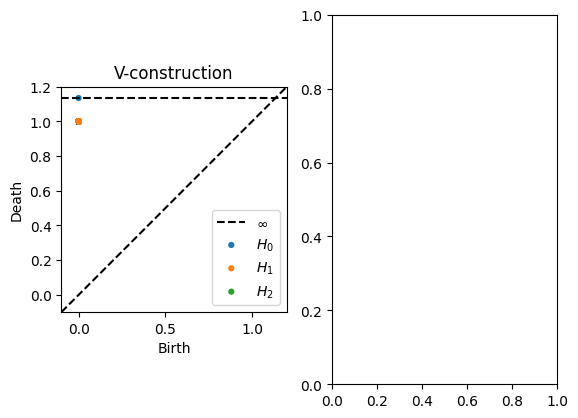

In [16]:
import persim
import matplotlib.pyplot as plt

pd = labels_res
pds = [pd[pd[:,0] == i] for i in range(3)]
print("Betti numbers: ",[len(pds[i]) for i in range(len(pds))])

fig,axs = plt.subplots(1,2)
persim.plot_diagrams([p[:,1:3] for p in pds], ax=axs[0], title='V-construction')


### Drive

In [26]:
import SimpleITK as sitk
import persim
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt

pre_path = '/mnt/40B2A1DBB2A1D5A6/lyx/project/Nerve/Reference/DSCNet/DSCNet_2D_opensource/Results/DRIVE/DSCNet/02.nii.gz'
lb_path = '/mnt/40B2A1DBB2A1D5A6/lyx/project/Nerve/Reference/DSCNet/DSCNet_2D_opensource/Data/DRIVE/Label_Te/02.nii.gz'

pre = sitk.ReadImage(pre_path)
lb = sitk.ReadImage(lb_path)

pre = sitk.GetArrayFromImage(pre)
lb = sitk.GetArrayFromImage(lb)

pre[pre >= 0.5] = 1
pre[pre < 0.5] = 0

lb[lb>0] = 1

def dt(img, radius=15,signed=False):
#    bw_img = (img >= rank.otsu(img, disk(radius)))
    dt_img = distance_transform_edt(img)
    if signed:
        dt_img -= distance_transform_edt(~img)
    return(dt_img)


In [40]:
eval_two_volume_betti(pre, lb, noise=1e-3, patch_size=(64,64), num=100)

{0: 0.19, 1: 3.93, 2: 0.0}

In [30]:
beta0_list = []
beta1_list = []
for f in os.listdir(os.path.dirname(pre_path)):
    file_dir = os.path.dirname(pre_path)
    label_dir = os.path.dirname(lb_path)

    f_path = os.path.join(file_dir, f)
    l_path = os.path.join(label_dir, f)

    pre = sitk.ReadImage(f_path)
    lb = sitk.ReadImage(l_path)

    pre = sitk.GetArrayFromImage(pre)
    lb = sitk.GetArrayFromImage(lb)

    pre[pre >= 0.5] = 1
    pre[pre < 0.5] = 0

    lb[lb>0] = 1

    res = eval_two_volume_betti(pre, lb, noise=1e-3, patch_size=(64,64), num=100)
    beta0_list.append(res[0])
    beta1_list.append(res[1])

print(np.array(beta0_list).mean(), np.array(beta1_list).mean())

0.19799999999999998 9.981499999999999


Betti numbers:  [5, 0, 0]
Betti numbers:  [5, 0, 0]


/media/user/a7ede1e7-8011-4a0c-903a-6a8652a8de87/workspace/anaconda3/envs/lyx_sam2/lib/python3.12/site-packages/persim/visuals.py:87: RuntimeWarning: overflow encountered in cast
  diagrams = [dgm.astype(np.float32, copy=True) for dgm in diagrams]
/media/user/a7ede1e7-8011-4a0c-903a-6a8652a8de87/workspace/anaconda3/envs/lyx_sam2/lib/python3.12/site-packages/persim/visuals.py:87: RuntimeWarning: overflow encountered in cast
  diagrams = [dgm.astype(np.float32, copy=True) for dgm in diagrams]


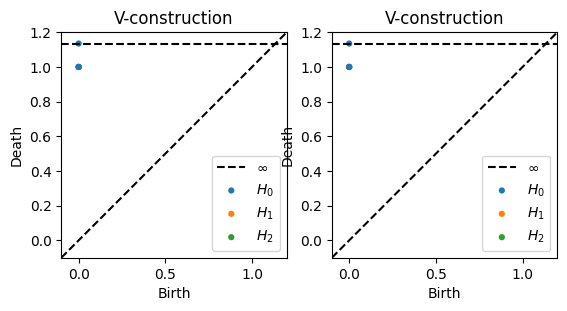

In [127]:

pre, lb = ramdon_cut(pre, lb, (64,64))

pre_res = cripser.computePH(pre, maxdim=1)
lb_res = cripser.computePH(lb, maxdim=1)

pd = pre_res
pds = [pd[pd[:,0] == i] for i in range(3)]
print("Betti numbers: ",[len(pds[i]) for i in range(len(pds))])

pd = lb_res
pds = [pd[pd[:,0] == i] for i in range(3)]
print("Betti numbers: ",[len(pds[i]) for i in range(len(pds))])

fig,axs = plt.subplots(1,2)
pd = pre_res
persim.plot_diagrams([p[:,1:3] for p in pds], ax=axs[0], title='V-construction')
pd = lb_res
persim.plot_diagrams([p[:,1:3] for p in pds], ax=axs[1], title='V-construction')

In [27]:
2194 * 5 / 150

73.13333333333334

### 欧拉特征

In [31]:
import numpy as np 
import os
from skimage import measure

In [32]:
def calculate_euler_characteristic(image):
    """
    计算二值图像的欧拉特征
    
    参数:
        image: 二值图像(numpy数组)，背景为0，前景为非0值
        
    返回:
        欧拉特征值
    """
    # 将图像转换为严格的二值图像(0和1)
    binary_image = (image > 0).astype(np.uint8)
    
    # 计算欧拉特征
    euler = measure.euler_number(binary_image, connectivity=8)
    
    return euler

In [33]:
calculate_euler_characteristic(pre)

65

In [34]:
def eval_two_volume_Euler(preds, labels, connectivity=4, patch_size=(16,16,16), num=100):

    if preds.dtype is not np.uint8:
        preds = preds.astype(np.uint8) 
    
    if labels.dtype is not np.uint8:
        labels = labels.astype(np.uint8)

    euler_diff = 0

    for i in range(num):
        preds_cut, labels_cut = ramdon_cut(preds, labels, patch_size=patch_size)
        preds_euler = measure.euler_number(preds_cut, connectivity=connectivity)
        lbs_euler = measure.euler_number(labels_cut, connectivity=connectivity)

        euler_diff += abs(preds_euler  - lbs_euler)

        
    
    euler_diff = euler_diff / num

    return euler_diff

In [70]:
eval_two_volume_Euler(preds, gts, patch_size=(16,16,16), num=500)

7.906

In [78]:
x = []
y = []
z = []

for i in range(100):
    j = np.random.randint(0, 148 - 16)
    x.append(j)

In [80]:
x = np.array(x)

In [85]:
def random_index(num, max_size, save_dir):
    new = {'x':[], 'y':[], 'z':[]}

    for k in new.keys():
        new[k] = np.random.randint(0, max_size, num)
        print(new[k])
        np.save(os.path.join(save_dir, f'index_{k}.npy'), new[k])
    


In [83]:
save_dir = '/mnt/40B2A1DBB2A1D5A6/lyx/project/Nerve/nerve/Trial/CONFIG'

In [99]:
indx_dir = '/mnt/40B2A1DBB2A1D5A6/lyx/project/Nerve/nerve/Trial/CONFIG'
axis = ['x', 'y', 'z']
patch_indx = []
for k in axis:
    indx_path = os.path.join(indx_dir, f'index_{k}.npy')
    patch_indx.append(np.load(indx_path).tolist())

patch_indx = np.array(patch_indx)

In [100]:
patch_indx[:,0]

array([116,  86,  60])